In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 0  – GLOBAL SETUP: imports ▸ paths ▸ flags ▸ constants
# ════════════════════════════════════════════════════════════════════════════════

# --- core libs
import numpy as np
import nibabel as nib
import pandas as pd

# --- imaging / DL
import cv2, matplotlib.pyplot as plt
from ultralytics import YOLO
from totalsegmentator.python_api import totalsegmentator

# --- misc libs
from pathlib import Path
from collections import Counter

# ── PATHS (EDIT HERE) ───────────────────────────────────────────────────────────
MODEL_PATH = Path(r"C:\Users\Ryan Krishna\Documents\Overscanning\yolo_runs\yolo11_pubic_symphysis_m_hardtrain\weights\best.pt")

NIFTI_DIR  = Path(r"D:\test_5_slow")
CSV_PATH   = NIFTI_DIR / "overscanning_results.csv"

# ── FLAGS ───────────────────────────────────────────────────────────────────────
DISPLAY_DETECTION = True     # draw green box on best slice
FAST_MODEL        = False    # TotalSegmentator "fast" mode
MULTI_LABEL_MASK  = True     # 1 = liver, 2 = spleen

# ── CONSTANTS ───────────────────────────────────────────────────────────────────
FINAL_CONF    = 0.20     # YOLO confidence threshold
BACKGROUND_HU = -300     # HU ≤ –300 → treated as air/outside body
model         = YOLO(str(MODEL_PATH))   # load once, reused everywhere

Found 6 NIfTI files

🔍 Detecting in test_5_slow\BMAB1_00000001\BMAB1_00000001_CA_OR_CAP_ROUTINE_20240920085414_8.nii.gz

0: 1024x1024 (no detections), 8.7ms
Speed: 3.6ms preprocess, 8.7ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.2ms
Speed: 3.5ms preprocess, 8.2ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.4ms
Speed: 3.8ms preprocess, 8.4ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.2ms
Speed: 3.8ms preprocess, 8.2ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.3ms
Speed: 3.9ms preprocess, 8.3ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.3ms
Speed: 3.8ms preprocess, 8.3ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 pubic_symphysis, 8.6ms
Speed: 3.7ms preprocess, 8.6ms 

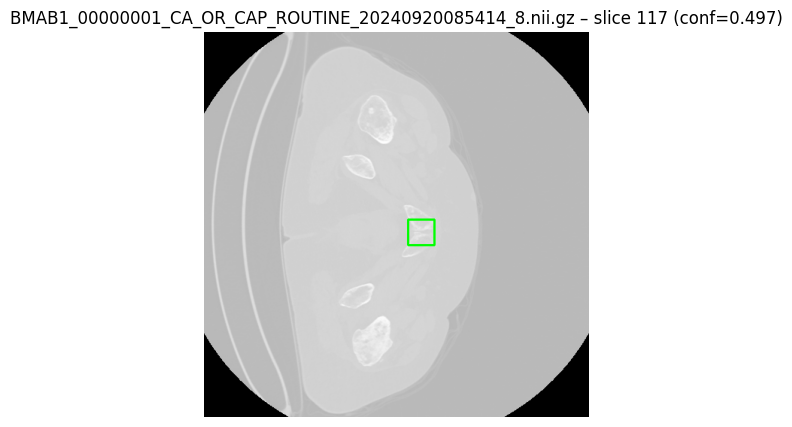

🔍 Detecting in test_5_slow\BMAB1_00000002\BMAB1_00000002_Abdomen_Pelvis_With_20240223205055_3.nii.gz

0: 1024x1024 (no detections), 20.8ms
Speed: 4.4ms preprocess, 20.8ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 21.1ms
Speed: 3.9ms preprocess, 21.1ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 22.5ms
Speed: 3.6ms preprocess, 22.5ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 21.2ms
Speed: 3.8ms preprocess, 21.2ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 21.0ms
Speed: 3.9ms preprocess, 21.0ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 21.8ms
Speed: 4.2ms preprocess, 21.8ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 21.3ms
Speed: 3.6ms preprocess, 21.3ms inferen

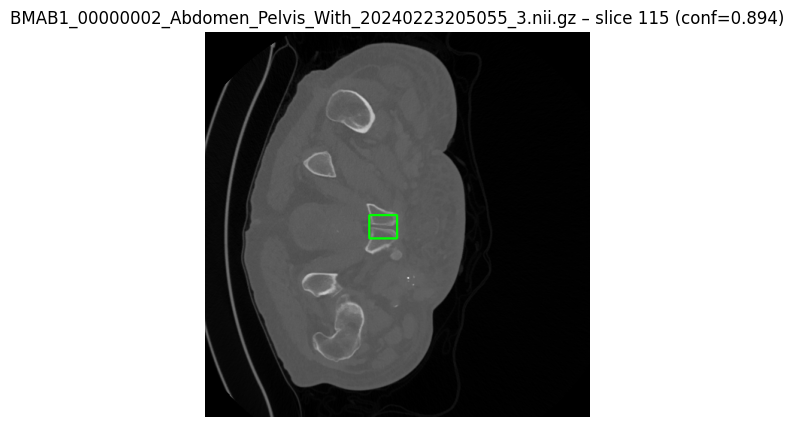

🔍 Detecting in test_5_slow\BMAB1_00000003\BMAB1_00000003_CA_OR_CAP_ROUTINE_20240905065620_8.nii.gz

0: 1024x1024 (no detections), 18.1ms
Speed: 4.1ms preprocess, 18.1ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 19.4ms
Speed: 4.2ms preprocess, 19.4ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 19.0ms
Speed: 3.8ms preprocess, 19.0ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 18.9ms
Speed: 4.2ms preprocess, 18.9ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 19.1ms
Speed: 3.9ms preprocess, 19.1ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 18.9ms
Speed: 4.1ms preprocess, 18.9ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 19.5ms
Speed: 4.3ms preprocess, 19.5ms inference

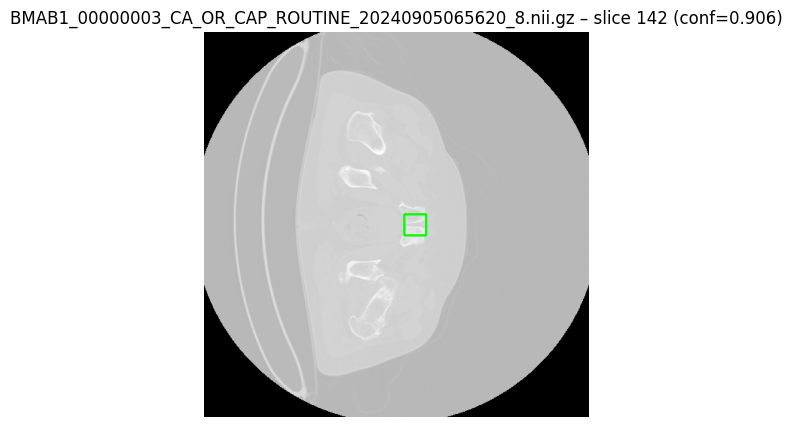

🔍 Detecting in test_5_slow\BMAB1_00000004\BMAB1_00000004_ABD_ABD_PELVIS_20240710154501_5.nii.gz

0: 1024x1024 (no detections), 8.6ms
Speed: 4.3ms preprocess, 8.6ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.5ms
Speed: 3.9ms preprocess, 8.5ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.2ms
Speed: 3.9ms preprocess, 8.2ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.4ms
Speed: 4.0ms preprocess, 8.4ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.6ms
Speed: 4.1ms preprocess, 8.6ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.5ms
Speed: 4.1ms preprocess, 8.5ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.8ms
Speed: 4.1ms preprocess, 8.8ms inference, 0.5ms postproce

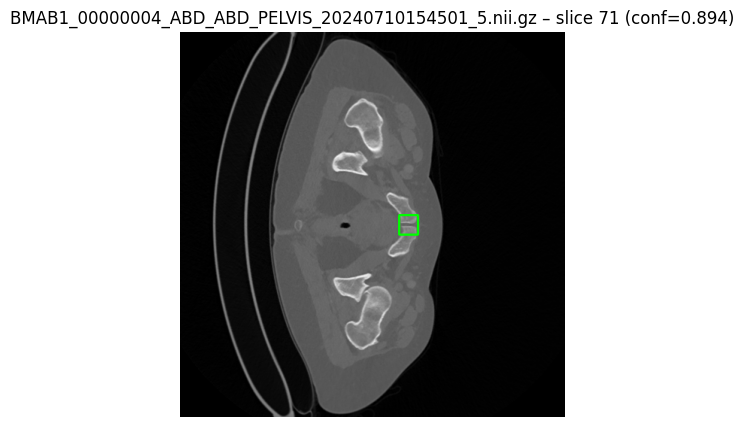

🔍 Detecting in test_5_slow\BMAB1_00000006\BMAB1_00000006_5.11_CHEST_ABD-PELVIS_ROUTINE_201-300_LBS_OR_ARMS_DOW_20240922141814_7.nii.gz

0: 1024x1024 (no detections), 8.4ms
Speed: 4.0ms preprocess, 8.4ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.0ms
Speed: 4.3ms preprocess, 8.0ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.1ms
Speed: 4.1ms preprocess, 8.1ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 pubic_symphysis, 7.9ms
Speed: 4.3ms preprocess, 7.9ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 pubic_symphysis, 12.8ms
Speed: 6.9ms preprocess, 12.8ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.5ms
Speed: 3.7ms preprocess, 8.5ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 9.4ms
Speed: 6.5ms

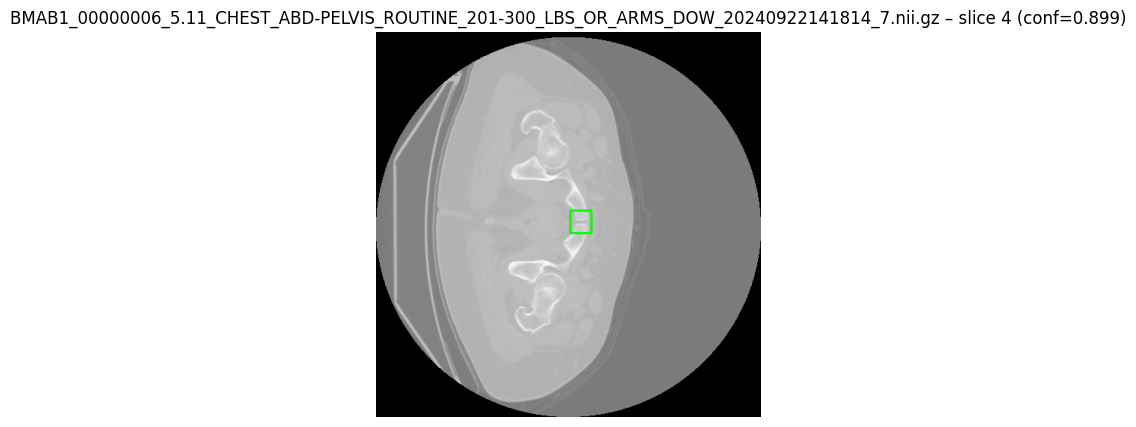

🔍 Detecting in test_5_slow\BMAB1_00000006\BMAB1_00000006_5.11_CHEST_ABD-PELVIS_ROUTINE_201-300_LBS_OR_ARMS_DOW_20240922141814_7_Eq_1.nii.gz

0: 1024x1024 (no detections), 8.2ms
Speed: 5.0ms preprocess, 8.2ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.0ms
Speed: 4.0ms preprocess, 8.0ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.0ms
Speed: 4.2ms preprocess, 8.0ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 11.2ms
Speed: 4.2ms preprocess, 11.2ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.3ms
Speed: 4.0ms preprocess, 8.3ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.0ms
Speed: 3.8ms preprocess, 8.0ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 7.8ms
Speed: 3.7m

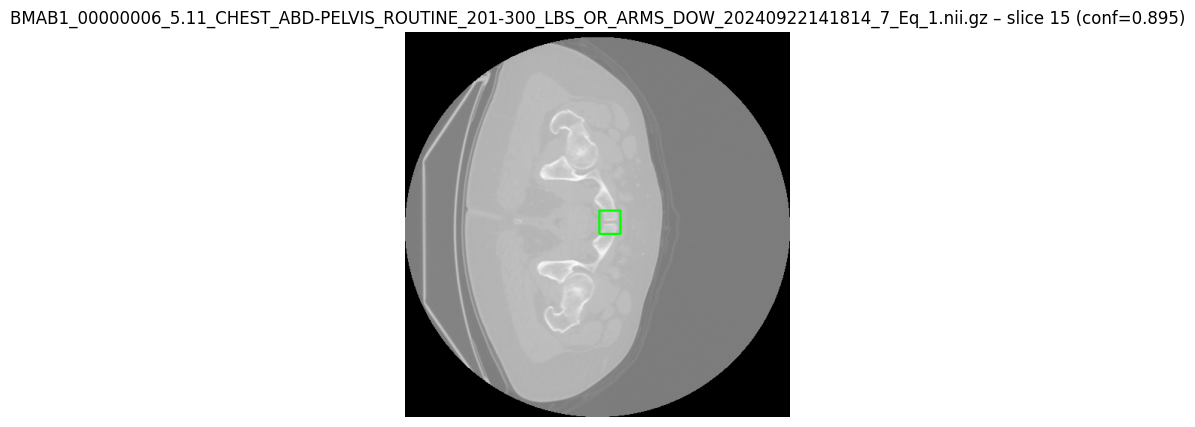


✅ Detected pubic symphysis in 6 / 6 scans


In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 1  – Pubic‑symphysis detection  → best_slice_dict  (with mid‑line + HU filter)
# ════════════════════════════════════════════════════════════════════════════════

def preprocess_slice(ct_slice: np.ndarray) -> np.ndarray:
    arr = ct_slice.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    arr = (arr * 255.0).astype(np.uint8)
    return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)

def find_best_symphysis_slice(ct_path: Path, show: bool = True) -> int | None:
    ct = nib.load(str(ct_path))
    H, W, Z = ct.shape
    vol = ct.get_fdata()

    best_conf, best_slice, best_box = -1.0, None, None
    for z in range(Z):
        img = preprocess_slice(vol[:, :, z])
        res = model.predict(img, conf=FINAL_CONF, device=0, save=False)[0]

        # Examine boxes on this slice, highest confidence first
        for b in sorted(res.boxes, key=lambda bb: float(bb.conf), reverse=True):
            conf           = float(b.conf)
            x1, y1, x2, y2 = b.xyxy[0].tolist()

            # ── 1) Air / outside‑body check ───────────────────────────────────
            centre_hu = float(vol[int((y1 + y2) / 2), int((x1 + x2) / 2), z])
            if centre_hu <= BACKGROUND_HU:
                continue

            # ── 2) Mid‑line check (±20 % of width) ────────────────────────────
            cx      = int((x1 + x2) / 2)
            img_mid = W // 2
            if abs(cx - img_mid) > (W * 0.20):
                continue

            # ── 3) Bone‑intensity check (mean HU in 20×20 window ≥150) ───────
            pad = 10
            x0, x1w = max(0, cx - pad), min(W, cx + pad)
            y0, y1w = max(0, int((y1 + y2) / 2) - pad), min(H, int((y1 + y2) / 2) + pad)
            roi_hu_mean = vol[y0:y1w, x0:x1w, z].mean()
            if roi_hu_mean < 150:
                continue

            # ── 4) Keep if highest confidence so far ─────────────────────────
            if conf > best_conf:
                best_conf, best_slice, best_box = conf, z, (x1, y1, x2, y2)
            break   # no need to consider lower‑confidence boxes on this slice

    if best_slice is None:
        print(f"❌ {ct_path.name}: no valid detection")
        return None

    if show:
        x1, y1, x2, y2 = best_box
        vis = preprocess_slice(vol[:, :, best_slice]).copy()
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        plt.figure(figsize=(5, 5)); plt.axis("off")
        plt.title(f"{ct_path.name} – slice {best_slice} (conf={best_conf:.3f})")
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.show()

    return best_slice


# ---------- run across all *.nii / *.nii.gz ----------
best_slice_dict = {}
nii_paths = sorted(NIFTI_DIR.rglob("*.nii*"))   # JSON ignored
print(f"Found {len(nii_paths)} NIfTI files\n")

for ct_file in nii_paths:
    print(f"🔍 Detecting in {ct_file.relative_to(NIFTI_DIR.parent)}")
    z = find_best_symphysis_slice(ct_file, show=DISPLAY_DETECTION)
    if z is not None:
        best_slice_dict[ct_file] = z

print(f"\n✅ Detected pubic symphysis in {len(best_slice_dict)} / {len(nii_paths)} scans")


In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 2  – Compute caudal overscan (pubic) → df_caudal
# ════════════════════════════════════════════════════════════════════════════════

rows_caudal = []

for ct_path, best_slice in best_slice_dict.items():
    ct_obj  = nib.load(str(ct_path))
    affine  = ct_obj.affine
    Z       = ct_obj.shape[2]

    # ── world‑space z of pubic symphysis slice ────────────────────────────────
    pubic_z = float((affine @ np.array([0, 0, best_slice, 1]))[2])

    # ── world‑space z of caudal scan edge (lowest z) ──────────────────────────
    end_z = min(
        float((affine @ np.array([0, 0, k, 1]))[2])
        for k in range(Z)
    )

    # ── overscan distance (always positive) ───────────────────────────────────
    caudal_mm = abs(end_z - pubic_z)

    rows_caudal.append({
        "file_name":          ct_path.name,
        "pubic_z_mm":         pubic_z,
        "scan_end_z_mm":      end_z,
        "caudal_overscan_mm": caudal_mm,
    })

df_caudal = pd.DataFrame(rows_caudal).sort_values("file_name")
print(f"✅ Caudal overscan calculated for {len(df_caudal)} scans")
df_caudal.head()

✅ Caudal overscan calculated for 6 scans


,file_name,pubic_z_mm,scan_end_z_mm,caudal_overscan_mm
0,BMAB1_00000001_CA_OR_CAP_ROUTINE_2024092008541...,1274.416992,1215.916992,58.5
1,BMAB1_00000002_Abdomen_Pelvis_With_20240223205...,-1027.099976,-1084.599976,57.5
2,BMAB1_00000003_CA_OR_CAP_ROUTINE_2024090506562...,1251.229004,1180.229004,71.0
3,BMAB1_00000004_ABD_ABD_PELVIS_20240710154501_5...,-655.299988,-726.299988,71.0
4,BMAB1_00000006_5.11_CHEST_ABD-PELVIS_ROUTINE_2...,-627.559998,-657.559998,30.0


In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 3  – TotalSegmentator (liver + spleen) → combined masks
# ════════════════════════════════════════════════════════════════════════════════
def ensure_liver_spleen_mask(ct_path: Path) -> Path:
    out_dir      = ct_path.parent / "ts_liver_spleen"
    liver_mask   = out_dir / "liver.nii.gz"
    spleen_mask  = out_dir / "spleen.nii.gz"
    merged_mask  = ct_path.parent / "liver_spleen_combined.nii.gz"

    if merged_mask.exists():
        return merged_mask

    # 1) run TotalSegmentator if needed
    if not (liver_mask.exists() and spleen_mask.exists()):
        out_dir.mkdir(exist_ok=True)
        totalsegmentator(
            ct_path, out_dir,
            roi_subset=["liver", "spleen"],
            task="total",
            fast=FAST_MODEL,
            device="gpu"
        )

    # 2) merge masks
    liver_img   = nib.load(liver_mask)
    spleen_img  = nib.load(spleen_mask)
    liver_data  = liver_img.get_fdata() > 0
    spleen_data = spleen_img.get_fdata() > 0

    if MULTI_LABEL_MASK:
        combined = np.zeros(liver_data.shape, dtype=np.uint8)
        combined[liver_data]  = 1
        combined[spleen_data] = 2
    else:
        combined = (liver_data | spleen_data).astype(np.uint8)

    merged_img = nib.Nifti1Image(combined, liver_img.affine, liver_img.header)
    nib.save(merged_img, merged_mask)

    # 3) delete individual masks
    for f in (liver_mask, spleen_mask):
        if f.exists():
            f.unlink()

    return merged_mask

# --- run segmentation (skip if combined already present) ---
for ct_path in nii_paths:
    rel = ct_path.relative_to(NIFTI_DIR.parent)
    print(f"▶ Segmentation check: {rel}")
    ensure_liver_spleen_mask(ct_path)

print("\n✓ Liver + spleen masks ensured for all scans")

▶ Segmentation check: test_5_slow\BMAB1_00000001\BMAB1_00000001_CA_OR_CAP_ROUTINE_20240920085414_8.nii.gz

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 6.80s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 17.72it/s]


  Predicted in 7.40s
Resampling...
  cropping from (512, 512, 915) to (385, 248, 339)
Resampling...
  Resampled in 1.30s
Predicting part 1 of 1 ...


100%|██████████| 4/4 [00:00<00:00,  5.09it/s]


  Predicted in 7.63s
Resampling...
Saving segmentations...
  Saved in 13.35s
▶ Segmentation check: test_5_slow\BMAB1_00000002\BMAB1_00000002_Abdomen_Pelvis_With_20240223205055_3.nii.gz

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 7.10s
Predicting...


...

  Predicted in 7.02s
Resampling...
Saving segmentations...
  Saved in 7.62s
▶ Segmentation check: test_5_slow\BMAB1_00000006\BMAB1_00000006_5.11_CHEST_ABD-PELVIS_ROUTINE_201-300_LBS_OR_ARMS_DOW_20240922141814_7.nii.gz

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 0.62s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 34.34it/s]


  Predicted in 6.38s
Resampling...
  cropping from (512, 512, 61) to (333, 227, 24)
Resampling...
  Resampled in 0.60s
Predicting part 1 of 1 ...


100%|██████████| 4/4 [00:00<00:00, 19.63it/s]


  Predicted in 6.92s
Resampling...
Saving segmentations...
  Saved in 4.31s
▶ Segmentation check: test_5_slow\BMAB1_00000006\BMAB1_00000006_5.11_CHEST_ABD-PELVIS_ROUTINE_201-300_LBS_OR_ARMS_DOW_20240922141814_7_Eq_1.nii.gz

✓ Liver + spleen masks ensured for all scans


In [23]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 4  – Cranial overscan  + merge with caudal → FINAL CSV (all metrics rounded)
# ════════════════════════════════════════════════════════════════════════════════
def cranial_overscan(ct_path: Path, mask_path: Path) -> tuple[int, int, int]:
    """
    Returns:
        cranial_mm      – rounded cranial overscan distance
        organ_z_mm      – rounded world‑z of highest liver/spleen slice
        scan_start_mm   – rounded world‑z of cranial scan edge used
    """
    ct_img   = nib.load(str(ct_path))
    mask_img = nib.load(str(mask_path))
    affine   = ct_img.affine
    Z        = ct_img.shape[2]
    mask_np  = mask_img.get_fdata()

    seg_slices = np.where(mask_np.any(axis=(0, 1)))[0]
    if seg_slices.size == 0:
        raise RuntimeError(f"{ct_path.name}: empty combined mask")

    # world‑space z for each segmented slice
    z_coords = [
        (k, float((affine @ np.array([0, 0, k, 1]))[2]))
        for k in seg_slices
    ]
    z_edge0 = float((affine @ np.array([0, 0,      0, 1]))[2])
    z_edgeN = float((affine @ np.array([0, 0, Z - 1, 1]))[2])

    highest_slice, highest_z = max(z_coords, key=lambda t: t[1])
    if abs(z_edge0 - highest_z) > abs(z_edgeN - highest_z):
        highest_slice, highest_z = min(z_coords, key=lambda t: t[1])

    over0 = abs(z_edge0 - highest_z)
    overN = abs(z_edgeN - highest_z)
    cranial_mm     = int(round(min(over0, overN)))
    scan_start_mm  = int(round(z_edge0 if over0 < overN else z_edgeN))
    organ_z_mm     = int(round(highest_z))

    return cranial_mm, organ_z_mm, scan_start_mm


# ── build cranial DataFrame ─────────────────────────────────────────────────────
rows_cranial = []
for ct_path in nii_paths:
    mask_path = ct_path.parent / "liver_spleen_combined.nii.gz"
    cranial_mm, organ_z_mm, scan_start_mm = cranial_overscan(ct_path, mask_path)
    rows_cranial.append({
        "file_name":           ct_path.name,
        "liver_spleen_z_mm":   organ_z_mm,
        "scan_start_z_mm":     scan_start_mm,
        "cranial_overscan_mm": cranial_mm,
    })

df_cranial = pd.DataFrame(rows_cranial)

# --- merge caudal + cranial on filename, cast to int, write CSV ----------------
df_final = (
    df_caudal
    .merge(df_cranial, on="file_name", how="inner")
    .sort_values("file_name")
)

# convert all numeric columns to integer so the CSV shows “58” instead of “58.0”
num_cols = df_final.select_dtypes(include="number").columns
df_final[num_cols] = df_final[num_cols].astype(int)

df_final.to_csv(CSV_PATH, index=False)
print(f"\n✅ All done. Final CSV saved to → {CSV_PATH.resolve()}")
df_final.head()


✅ All done. Final CSV saved to → D:\test_5_slow\overscanning_results.csv


,file_name,pubic_z_mm,scan_end_z_mm,caudal_overscan_mm,liver_spleen_z_mm,scan_start_z_mm,cranial_overscan_mm
0,BMAB1_00000001_CA_OR_CAP_ROUTINE_2024092008541...,1274,1215,58,1524,1673,148
1,BMAB1_00000002_Abdomen_Pelvis_With_20240223205...,-1027,-1084,57,-767,-593,174
2,BMAB1_00000003_CA_OR_CAP_ROUTINE_2024090506562...,1251,1180,71,1461,1640,180
3,BMAB1_00000004_ABD_ABD_PELVIS_20240710154501_5...,-655,-726,71,-428,-249,179
4,BMAB1_00000006_5.11_CHEST_ABD-PELVIS_ROUTINE_2...,-627,-657,30,-365,-208,158
